In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_style('darkgrid')

In [2]:
df=pd.read_csv("D:\DATA ANALYST-DATA SCIENTIST\MY PROJECT 2025\HR FILE\Human Resource Performance & Retention Analysis\HR_Data.csv")
df.head()

,Unnamed: 0,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR
0,0,EMP0000001,Joshua Nguyen,IT,Software Engineer,2011-08-10,"Isaacland, Denmark",5,14,Resigned,On-site,1585363
1,1,EMP0000002,Julie Williams,Marketing,SEO Specialist,2018-03-02,"Anthonyside, Costa Rica",2,7,Active,On-site,847686
2,2,EMP0000003,Alyssa Martinez,HR,HR Manager,2023-03-20,"Port Christinaport, Saudi Arabia",1,2,Active,On-site,1430084
3,3,EMP0000004,Nicholas Valdez,IT,Software Engineer,2023-10-12,"Port Shelbychester, Antigua and Barbuda",1,1,Active,On-site,990689
4,4,EMP0000005,Joel Hendricks,Operations,Logistics Coordinator,2024-12-09,"Lake Kimberly, Palestinian Territory",5,0,Active,On-site,535082


In [3]:
df.shape

(2000000, 12)

In [4]:
df.describe()

,Unnamed: 0,Performance_Rating,Experience_Years,Salary_INR
count,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06
mean,9.999995e+05,3.000148e+00,5.010287e+00,8.968878e+05
std,5.773504e+05,1.413973e+00,3.608823e+00,4.026103e+05
min,0.000000e+00,1.000000e+00,0.000000e+00,3.000000e+05
25%,4.999998e+05,2.000000e+00,2.000000e+00,6.163460e+05
50%,9.999995e+05,3.000000e+00,5.000000e+00,8.110265e+05
75%,1.499999e+06,4.000000e+00,8.000000e+00,1.073745e+06
max,1.999999e+06,5.000000e+00,1.500000e+01,2.999976e+06


In [5]:
df.describe(include='object')

,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Status,Work_Mode
count,2000000,2000000,2000000,2000000,2000000,2000000,2000000,2000000
unique,2000000,467487,7,29,5479,1593497,4,2
top,EMP0000001,Michael Smith,IT,Software Engineer,2022-10-31,"Lake Michael, Congo",Active,On-site
freq,1,1014,601042,300358,622,20,1401558,1199109


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 12 columns):
 #   Column              Dtype 
---  ------              ----- 
 0   Unnamed: 0          int64 
 1   Employee_ID         object
 2   Full_Name           object
 3   Department          object
 4   Job_Title           object
 5   Hire_Date           object
 6   Location            object
 7   Performance_Rating  int64 
 8   Experience_Years    int64 
 9   Status              object
 10  Work_Mode           object
 11  Salary_INR          int64 
dtypes: int64(4), object(8)
memory usage: 183.1+ MB


# **Data_Cleaning**

In [7]:
df['Hire_Date']=pd.to_datetime(df['Hire_Date'])

In [8]:
df.isna().sum()

Unnamed: 0            0
Employee_ID           0
Full_Name             0
Department            0
Job_Title             0
Hire_Date             0
Location              0
Performance_Rating    0
Experience_Years      0
Status                0
Work_Mode             0
Salary_INR            0
dtype: int64

In [9]:
df.dropna(inplace=True)

In [10]:
df.duplicated().sum()

0

# **Fiture_Engineering**

In [11]:
Q1=df['Salary_INR'].quantile(0.25)
Q3=df['Salary_INR'].quantile(0.75)
IQR=Q3-Q1
lower_band=Q1-(1.5*IQR)
upper_band=Q3+(1.5*IQR)

In [12]:
def app(x):
  if x>upper_band:
    return 'High Earner'
  elif x<lower_band:
    return 'Low Earner'
  else:
    return 'Mid Earner'

df['Salary_level']=df['Salary_INR'].apply(app)

In [13]:
df['Experience_Years'].unique()

array([14,  7,  2,  1,  0,  4,  9,  5,  6,  8,  3, 10, 11, 12, 13, 15],
      dtype=int64)

In [14]:
def experience_level(x):
    if x < 2:
        return 'Junior'
    elif x < 6:
        return 'Mid-Level'
    elif x < 10:
        return 'Senior'
    else:
        return 'Expert'

df['Experience_Level'] = df['Experience_Years'].apply(experience_level)


In [15]:
df['hire_year']=df['Hire_Date'].dt.year

# **EDA & Visualization**

In [16]:
df['Department'].unique()

array(['IT', 'Marketing', 'HR', 'Operations', 'Finance', 'Sales', 'R&D'],
      dtype=object)

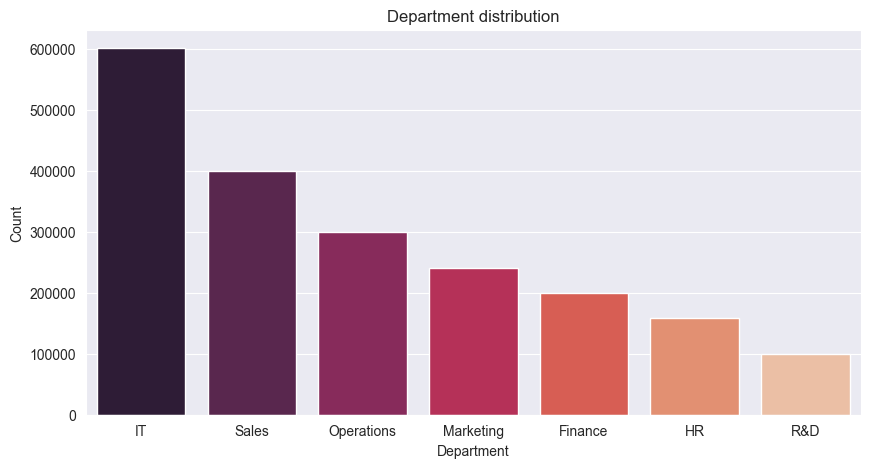

In [17]:
plt.figure(figsize=(10,5))
ord=df['Department'].value_counts().index
sns.countplot(data=df,x='Department',palette='rocket',order=ord)
plt.xlabel('Department')
plt.ylabel('Count')
plt.title('Department distribution')
plt.show()

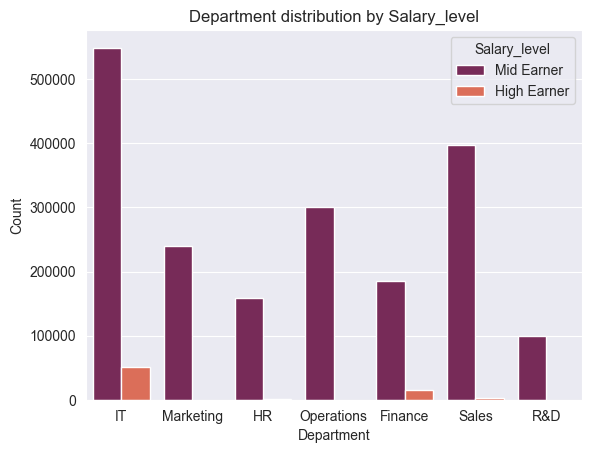

In [18]:
ord=df['Department'].value_counts().index
sns.countplot(data=df,x='Department',palette='rocket',hue='Salary_level')
plt.xlabel('Department')
plt.ylabel('Count')
plt.title('Department distribution by Salary_level')
plt.show()

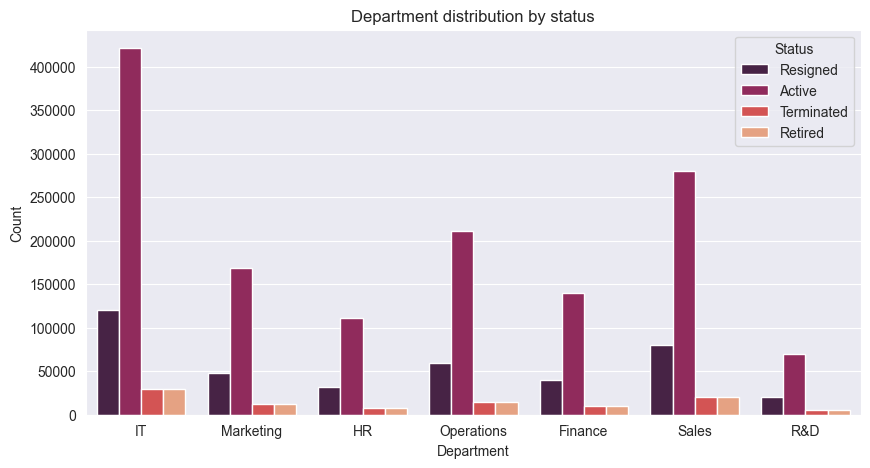

In [19]:
plt.figure(figsize=(10,5))
sns.countplot(data=df,x='Department',hue='Status',palette='rocket')
plt.xlabel('Department')
plt.ylabel('Count')
plt.title('Department distribution by status')
plt.show()

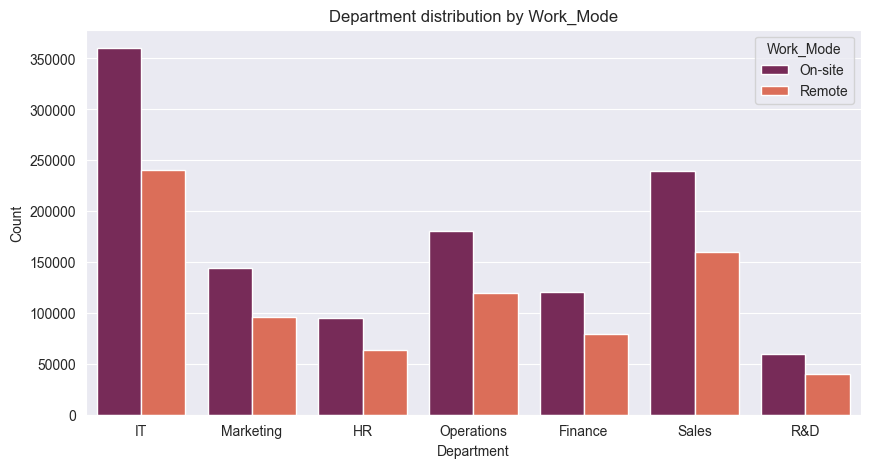

In [20]:
plt.figure(figsize=(10,5))
sns.countplot(data=df,x='Department',hue='Work_Mode',palette='rocket')
plt.xlabel('Department')
plt.ylabel('Count')
plt.title('Department distribution by Work_Mode')
plt.show()

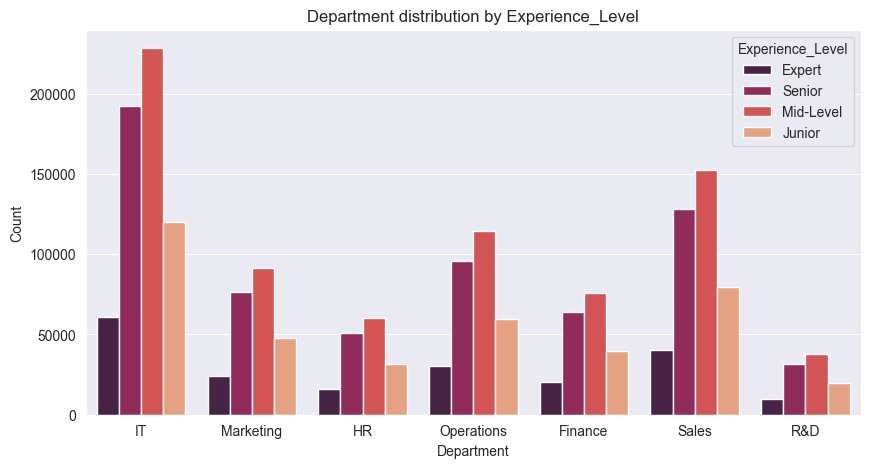

In [21]:
plt.figure(figsize=(10,5))
sns.countplot(data=df,x='Department',hue='Experience_Level',palette='rocket')
plt.xlabel('Department')
plt.ylabel('Count')
plt.title('Department distribution by Experience_Level')
plt.show()

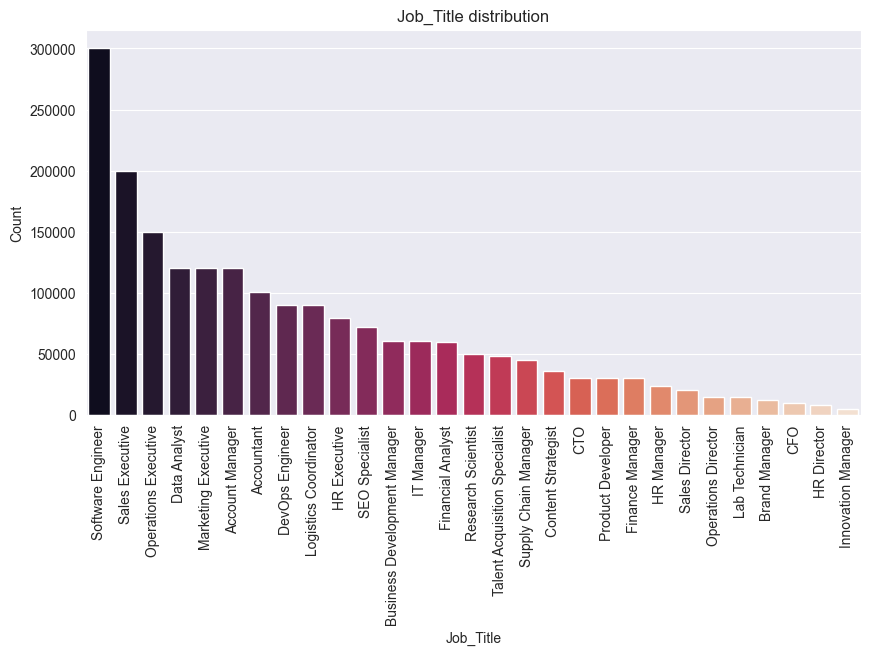

In [22]:
plt.figure(figsize=(10,5))
ord=df['Job_Title'].value_counts().index
sns.countplot(data=df,x='Job_Title',palette='rocket',order=ord)
plt.xlabel('Job_Title')
plt.ylabel('Count')
plt.title('Job_Title distribution')
plt.xticks(rotation=90)
plt.show()

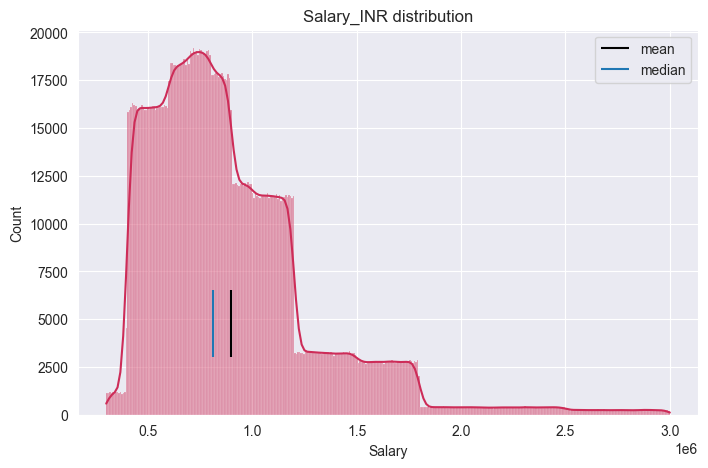

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(data=df,x='Salary_INR',kde=True,color='#CD2C58')
plt.vlines(x=df['Salary_INR'].mean(),ymin=3000,ymax=6500,label='mean',colors='black')
plt.vlines(x=df['Salary_INR'].median(),ymin=3000,ymax=6500,label='median')
plt.legend()
plt.xlabel('Salary')
plt.ylabel('Count')
plt.title('Salary_INR distribution')
plt.show()

In [24]:
df.loc[df['Salary_INR']==df['Salary_INR'].max()]

,Unnamed: 0,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR,Salary_level,Experience_Level,hire_year
1697605,1697605,EMP1697606,Kathryn Owens,IT,IT Manager,2018-02-22,"Adamsborough, Greenland",5,7,Active,Remote,2999976,High Earner,Senior,2018


In [25]:
df.loc[df['Salary_INR']==df['Salary_INR'].min()]


,Unnamed: 0,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR,Salary_level,Experience_Level,hire_year
1681045,1681045,EMP1681046,Sue Solis,HR,HR Executive,2021-02-09,"South Stacymouth, Grenada",4,4,Resigned,On-site,300000,Mid Earner,Mid-Level,2021


In [26]:
p=df.groupby('Department')['Salary_INR'].mean().sort_values(ascending=False)
p

Department
IT            1.129858e+06
Finance       9.404117e+05
R&D           8.003772e+05
Sales         7.929579e+05
Marketing     7.699362e+05
Operations    7.546263e+05
HR            7.438536e+05
Name: Salary_INR, dtype: float64

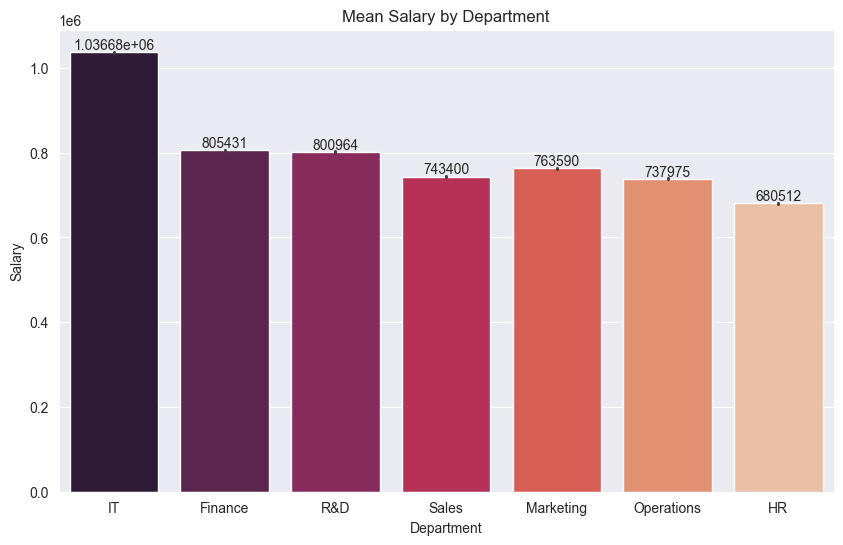

In [27]:
plt.figure(figsize=(10,6))
g=sns.barplot(data=df,x='Department',y='Salary_INR',palette='rocket',order=p.index,estimator='median')
plt.xlabel('Department')
plt.ylabel('Salary')
plt.title('Mean Salary by Department')
for i in g.containers:
    g.bar_label(i)
plt.show()

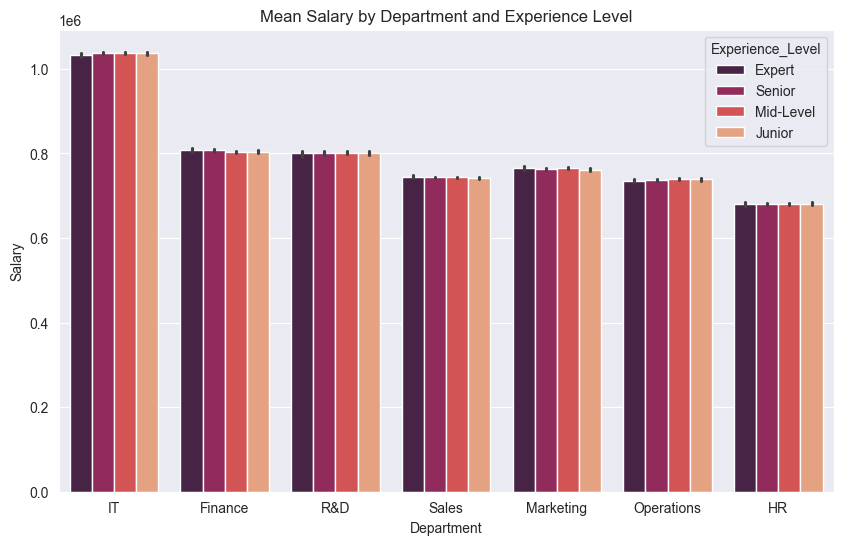

In [28]:
plt.figure(figsize=(10,6))
g=sns.barplot(data=df,x='Department',y='Salary_INR',palette='rocket',order=p.index,hue='Experience_Level',estimator='median')
plt.xlabel('Department')
plt.ylabel('Salary')
plt.title('Mean Salary by Department and Experience Level')
plt.show()

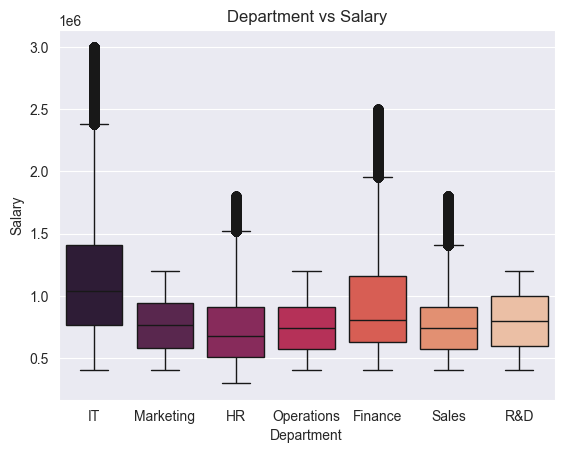

In [29]:
sns.boxplot(data=df,x='Department',y='Salary_INR',palette='rocket')
plt.xlabel('Department')
plt.ylabel('Salary')
plt.title('Department vs Salary')
plt.show()

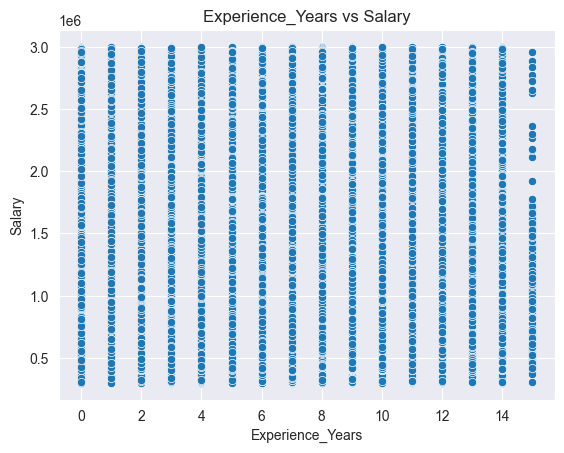

In [30]:
sns.scatterplot(data=df,x='Experience_Years',y='Salary_INR',palette='rocket')
plt.xlabel('Experience_Years')
plt.ylabel('Salary')
plt.title('Experience_Years vs Salary')
plt.show()

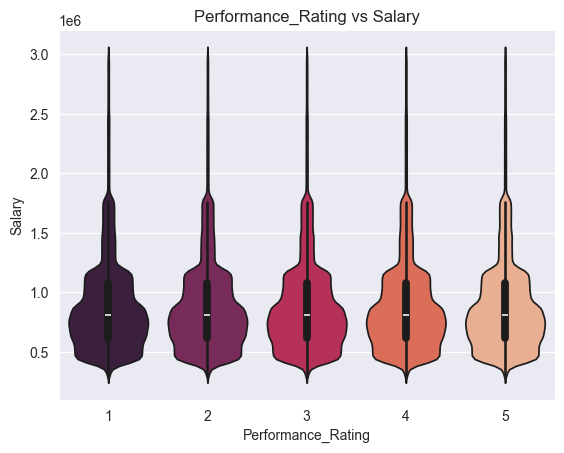

In [31]:
sns.violinplot(data=df,x='Performance_Rating',y='Salary_INR',palette='rocket')
plt.xlabel('Performance_Rating')
plt.ylabel('Salary')
plt.title('Performance_Rating vs Salary')
plt.show()

In [32]:
p1=df.pivot_table(index='Department',values='Performance_Rating',aggfunc='median')
p1.reset_index(inplace=True)
p1

,Department,Performance_Rating
0,Finance,3.0
1,HR,3.0
2,IT,3.0
3,Marketing,3.0
4,Operations,3.0
5,R&D,3.0
6,Sales,3.0


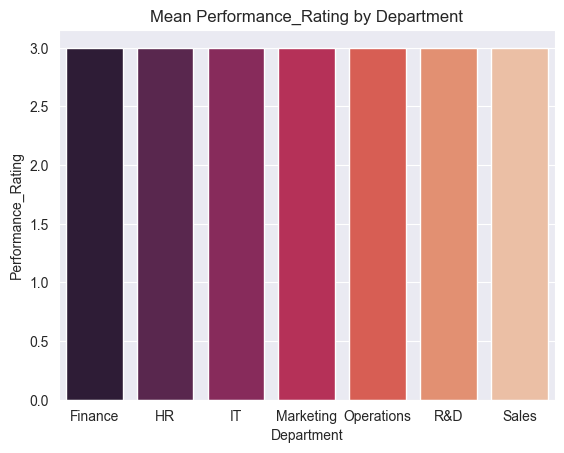

In [33]:
sns.barplot(data=p1,x='Department',y='Performance_Rating',palette='rocket')
plt.xlabel('Department')
plt.ylabel('Performance_Rating')
plt.title('Mean Performance_Rating by Department')
plt.show()

In [34]:
p1=df.pivot_table(index='Experience_Level',values='Performance_Rating',aggfunc='median')
p1.reset_index(inplace=True)
p1

,Experience_Level,Performance_Rating
0,Expert,3.0
1,Junior,3.0
2,Mid-Level,3.0
3,Senior,3.0


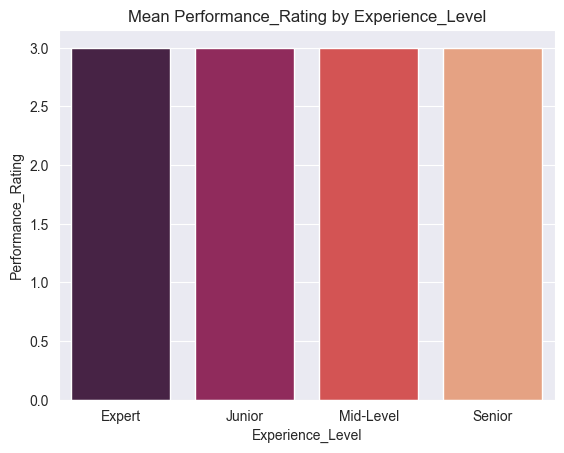

In [35]:
sns.barplot(data=p1,x='Experience_Level',y='Performance_Rating',palette='rocket')
plt.xlabel('Experience_Level')
plt.ylabel('Performance_Rating')
plt.title('Mean Performance_Rating by Experience_Level')
plt.show()

In [36]:
df_IT=df[df['Department']=='IT']
df_HR=df[df['Department']=='HR']
df_Sales=df[df['Department']=='Sales']
df_Finance=df[df['Department']=='Finance']
df_Operations=df[df['Department']=='Operations']
df_Marketing=df[df['Department']=='Marketing']
df_RD=df[df['Department']=='R&D']

In [37]:
IT_count=df_IT['Status'].value_counts()
HR_count=df_HR['Status'].value_counts()
Sales_count=df_Sales['Status'].value_counts()
Finance_count=df_Finance['Status'].value_counts()
Operations_count=df_Operations['Status'].value_counts()
Marketing_count=df_Marketing['Status'].value_counts()
RD_count=df_RD['Status'].value_counts()

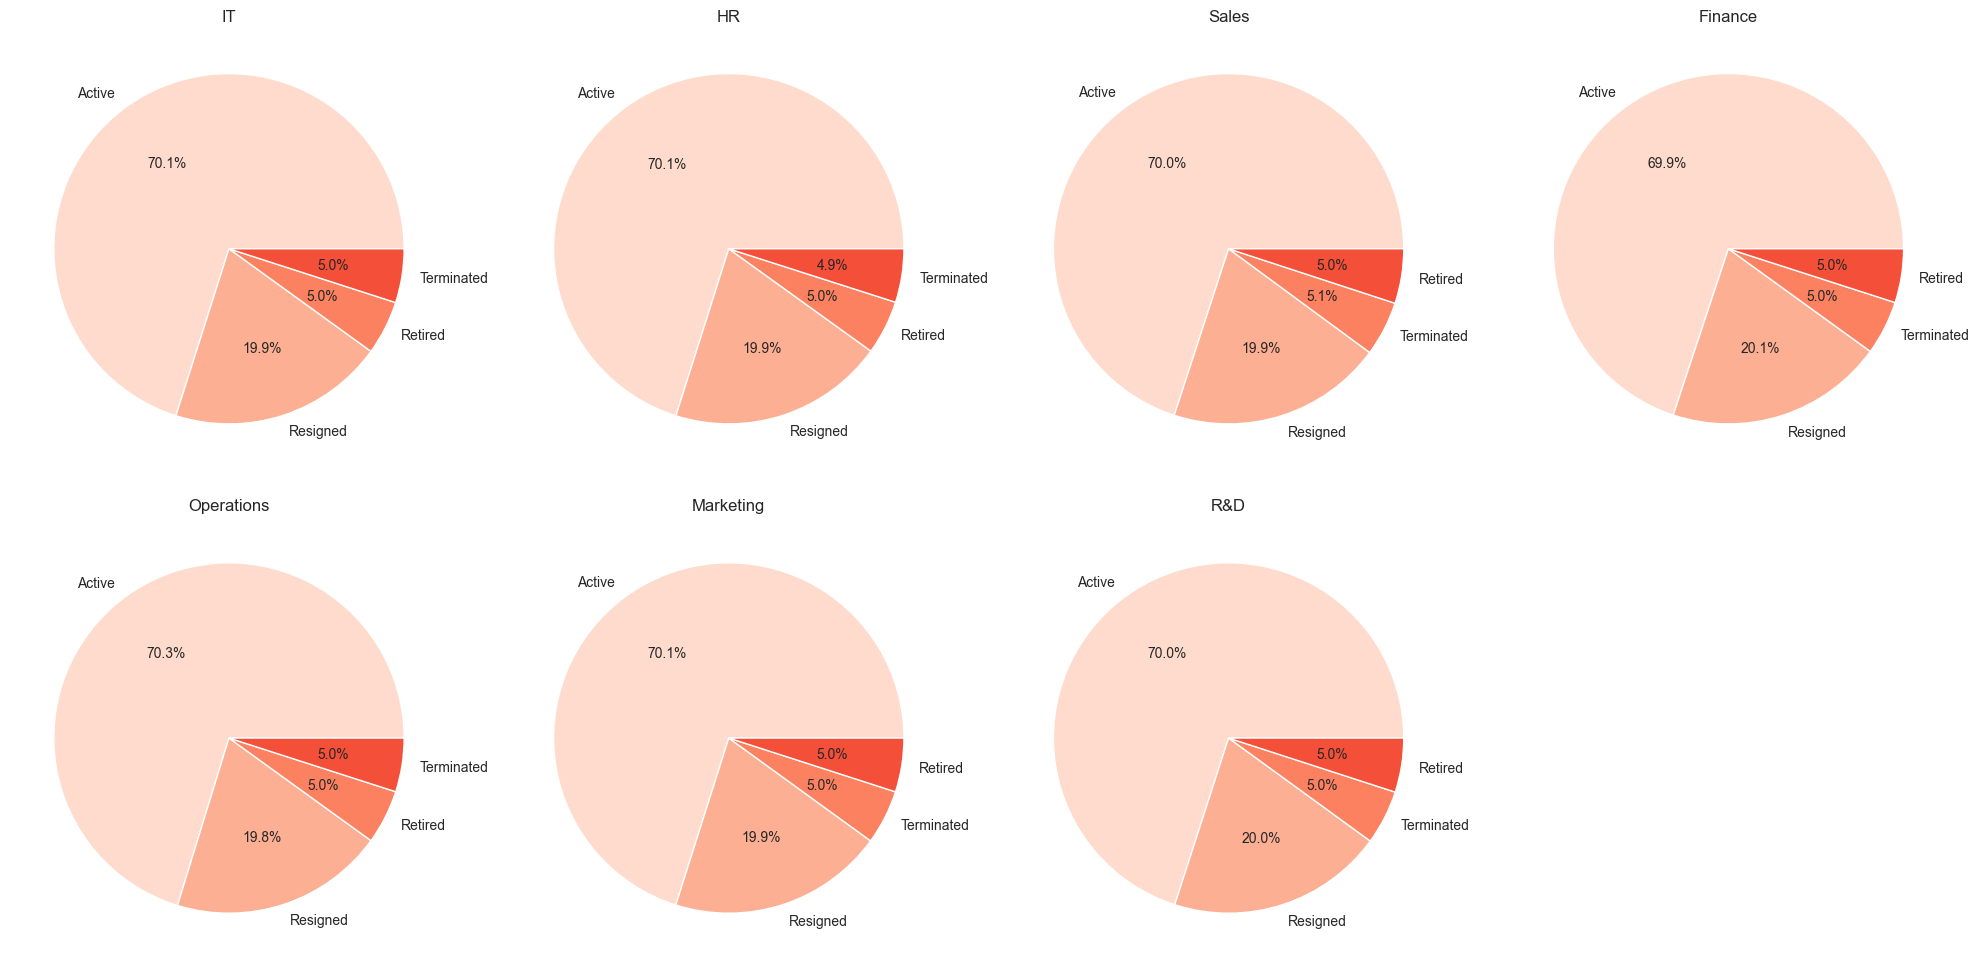

In [38]:
fig,ax=plt.subplots(2,4,figsize=(20,10))
ax[0,0].pie(IT_count,labels=IT_count.index,autopct='%1.1f%%',colors=sns.color_palette('Reds'))
ax[0,0].set_title('IT')

ax[0,1].pie(HR_count,labels=HR_count.index,autopct='%1.1f%%',colors=sns.color_palette('Reds'))
ax[0,1].set_title('HR')

ax[0,2].pie(Sales_count,labels=Sales_count.index,autopct='%1.1f%%',colors=sns.color_palette('Reds'))
ax[0,2].set_title('Sales')

ax[0,3].pie(Finance_count,labels=Finance_count.index,autopct='%1.1f%%',colors=sns.color_palette('Reds'))
ax[0,3].set_title('Finance')

ax[1,0].pie(Operations_count,labels=Operations_count.index,autopct='%1.1f%%',colors=sns.color_palette('Reds'))
ax[1,0].set_title('Operations')

ax[1,1].pie(Marketing_count,labels=Marketing_count.index,autopct='%1.1f%%',colors=sns.color_palette('Reds'))
ax[1,1].set_title('Marketing')

ax[1,2].pie(RD_count,labels=RD_count.index,autopct='%1.1f%%',colors=sns.color_palette('Reds'))
ax[1,2].set_title('R&D')

ax[1,3].set_visible(False)

plt.tight_layout()

In [39]:
p=df.pivot_table(index='hire_year',values='Employee_ID',aggfunc='count')
p.reset_index(inplace=True)
p

,hire_year,Employee_ID
0,2010,15520
1,2011,40089
2,2012,39765
3,2013,39988
4,2014,40202
5,2015,85984
6,2016,160249
7,2017,160363
8,2018,159658
9,2019,160202


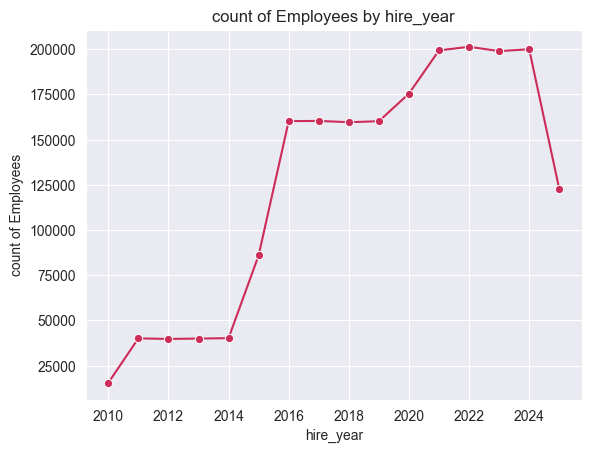

In [40]:
sns.lineplot(data=p,x='hire_year',y='Employee_ID',marker='o',color='#CD2C58')
plt.xlabel('hire_year')
plt.ylabel('count of Employees')
plt.title('count of Employees by hire_year')
plt.show()

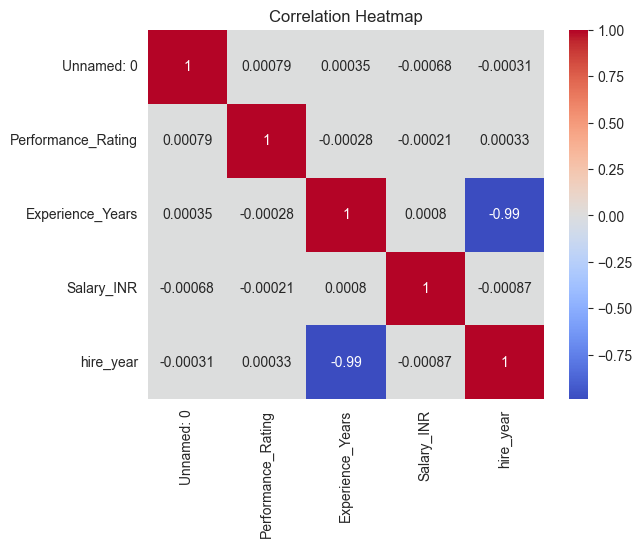

In [41]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()